In [35]:
# import libraries 
import os,warnings,cartopy
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import xarray as xr
import pandas as pd
from datetime import datetime
from scipy import stats, signal
from scipy.stats import false_discovery_control

warnings.filterwarnings('ignore') # Turns off warnings

## Read in and Prepare Data

In [36]:
ds = xr.open_dataset('storm_rainfall.nc')

lat_mask = (ds.lat >= 25) & (ds.lat <= 49)
lon_mask = (ds.lon >= -105) & (ds.lon <= -67)

rain = ds.sel(lat=lat_mask, lon=lon_mask)
rain = rain.where(rain != 0)

del ds

## Calculate Rain Rate

In [37]:
rr = (rain.rain / rain.hits).where(rain.hits > 0)

## Subset to first 15 years and last 15 years

In [38]:
re = rr.sel(storm=rr.year <= 2010)

In [39]:
rl = rr.sel(storm=rr.year > 2010)

## Find Climatology 

In [40]:
r_avg = rain.rain.mean(dim="storm", skipna=True)

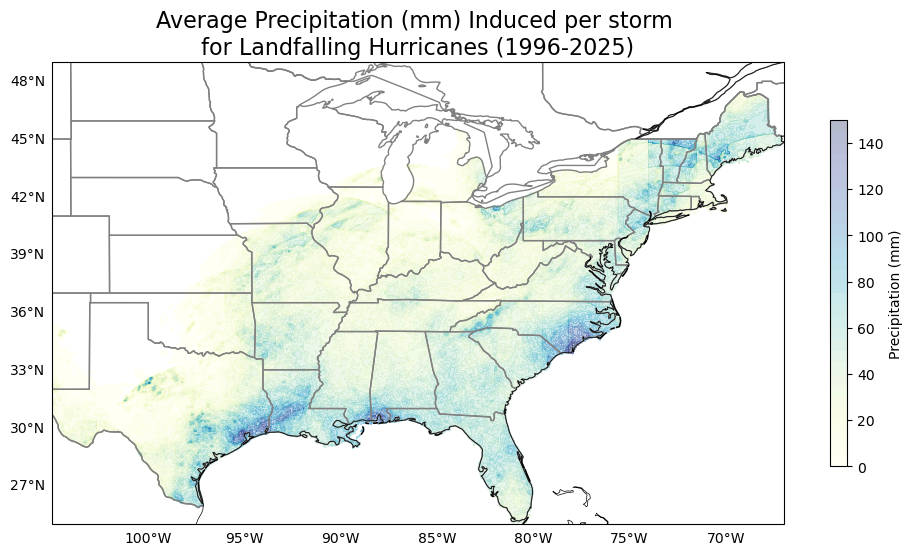

In [41]:
projection = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

levels = np.arange(0,155,5)

plt.figure(figsize=(12,6))
ax = plt.subplot(111, projection=projection)

# Map features
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='white')
ax.coastlines(resolution='50m', color='black', linewidth=0.5)
ax.set_extent([-105, -67, 25, 49], crs=ccrs.PlateCarree())
gl = ax.gridlines(crs=data_crs, draw_labels=True, dms=False, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False      
gl.ylines = False  

# Colorbar
cmap = plt.get_cmap(name='YlGnBu',lut=len(levels))

cs = ax.contourf(r_avg.lon, r_avg.lat, r_avg.values, levels=levels, transform=data_crs, cmap=cmap, alpha=0.3)

cbar = plt.colorbar(cs, ax=ax, shrink=0.75)
cbar.set_label('Precipitation (mm)')


plt.title('Average Precipitation (mm) Induced per storm \n for Landfalling Hurricanes (1996-2025) ', fontsize=16)
plt.savefig('Rainfall_Avg.png',facecolor='w',dpi=400)

## Create Composites

In [ ]:
## take per storm mean of early and late periods
re_avg = re.mean(dim="storm", skipna=True)
rl_avg = rl.mean(dim="storm", skipna=True)

In [43]:
J,I = re_avg.shape

In [ ]:
## compute composite difference
comp_diff = rl_avg - re_avg

n1 = len(rl.storm) # Number of late storms
n2 = len(re.storm) # Number of early storms
dof = n1 + n2 - 2 # Degrees of freedom

s1 = rl.std(dim='storm', skipna=True) # late storms standard deviation
s2 = re.std(dim='storm', skipna=True) # early storms standard deviation
sigma = (n1*pow(s1,2) + n2*pow(s2,2))/(n1+n2-1) # Pooled variance 

tStatistic = comp_diff/(np.sqrt(sigma)*np.sqrt(1/n1 + 1/n2)) # from in-class exercise

# p-value at each lat & lon for the two-sided t-test corresponding to each t-score.
pval = 2*stats.t.cdf(-abs(tStatistic),dof*np.ones(tStatistic.shape))


In [ ]:
## 95% significance level
alpha = 0.05
stipple = (pval<=alpha) 

## FDR Level
alpha_FDR = 0.1 

pval_flat = pval.flatten() 

## make adjustments from class notes to account for nans
mask = ~np.isnan(pval_flat)

adjusted = np.zeros_like(pval_flat)
adjusted[:] = np.nan

adjusted_valid = false_discovery_control(pval_flat[mask], axis=0, method='bh')
adjusted[mask] = adjusted_valid


stipple_FDR = (adjusted < alpha_FDR).reshape(J, I)


## find how many grid points are significant for each method
n_total = J * I
n_tscore = np.sum(stipple) # standard t-test
n_fdr = np.sum(stipple_FDR)

print(f'Total gridpoints : {n_total}')
print(f'Significant (t-test alpha={alpha}): {n_tscore}  ({100*n_tscore/n_total:.1f}%)')
print(f'Significant (FDR  q={alpha_FDR}): {n_fdr}   ({100*n_fdr/n_total:.1f}%)')



## find the effective p-value threshold used by BH
M = pval_flat.size

sorted_p = np.sort(pval_flat)
K = np.arange(1, pval_flat.size + 1) # ranks
bh_thresh_candidates = sorted_p[sorted_p <= (K / M) * alpha_FDR]
p_FDR_threshold = bh_thresh_candidates[-1] if bh_thresh_candidates.size > 0 else 0.0
print(f'BH p-value threshold used : {p_FDR_threshold:.5f}')


Total gridpoints : 525312
Significant (t-test alpha=0.05): 71834  (13.7%)
Significant (FDR  q=0.1): 70170   (13.4%)
BH p-value threshold used : 0.01058


## Plot results

In [ ]:
## make lat/lon grid for ease of use
lon, lat = np.meshgrid(comp_diff.lon, comp_diff.lat)

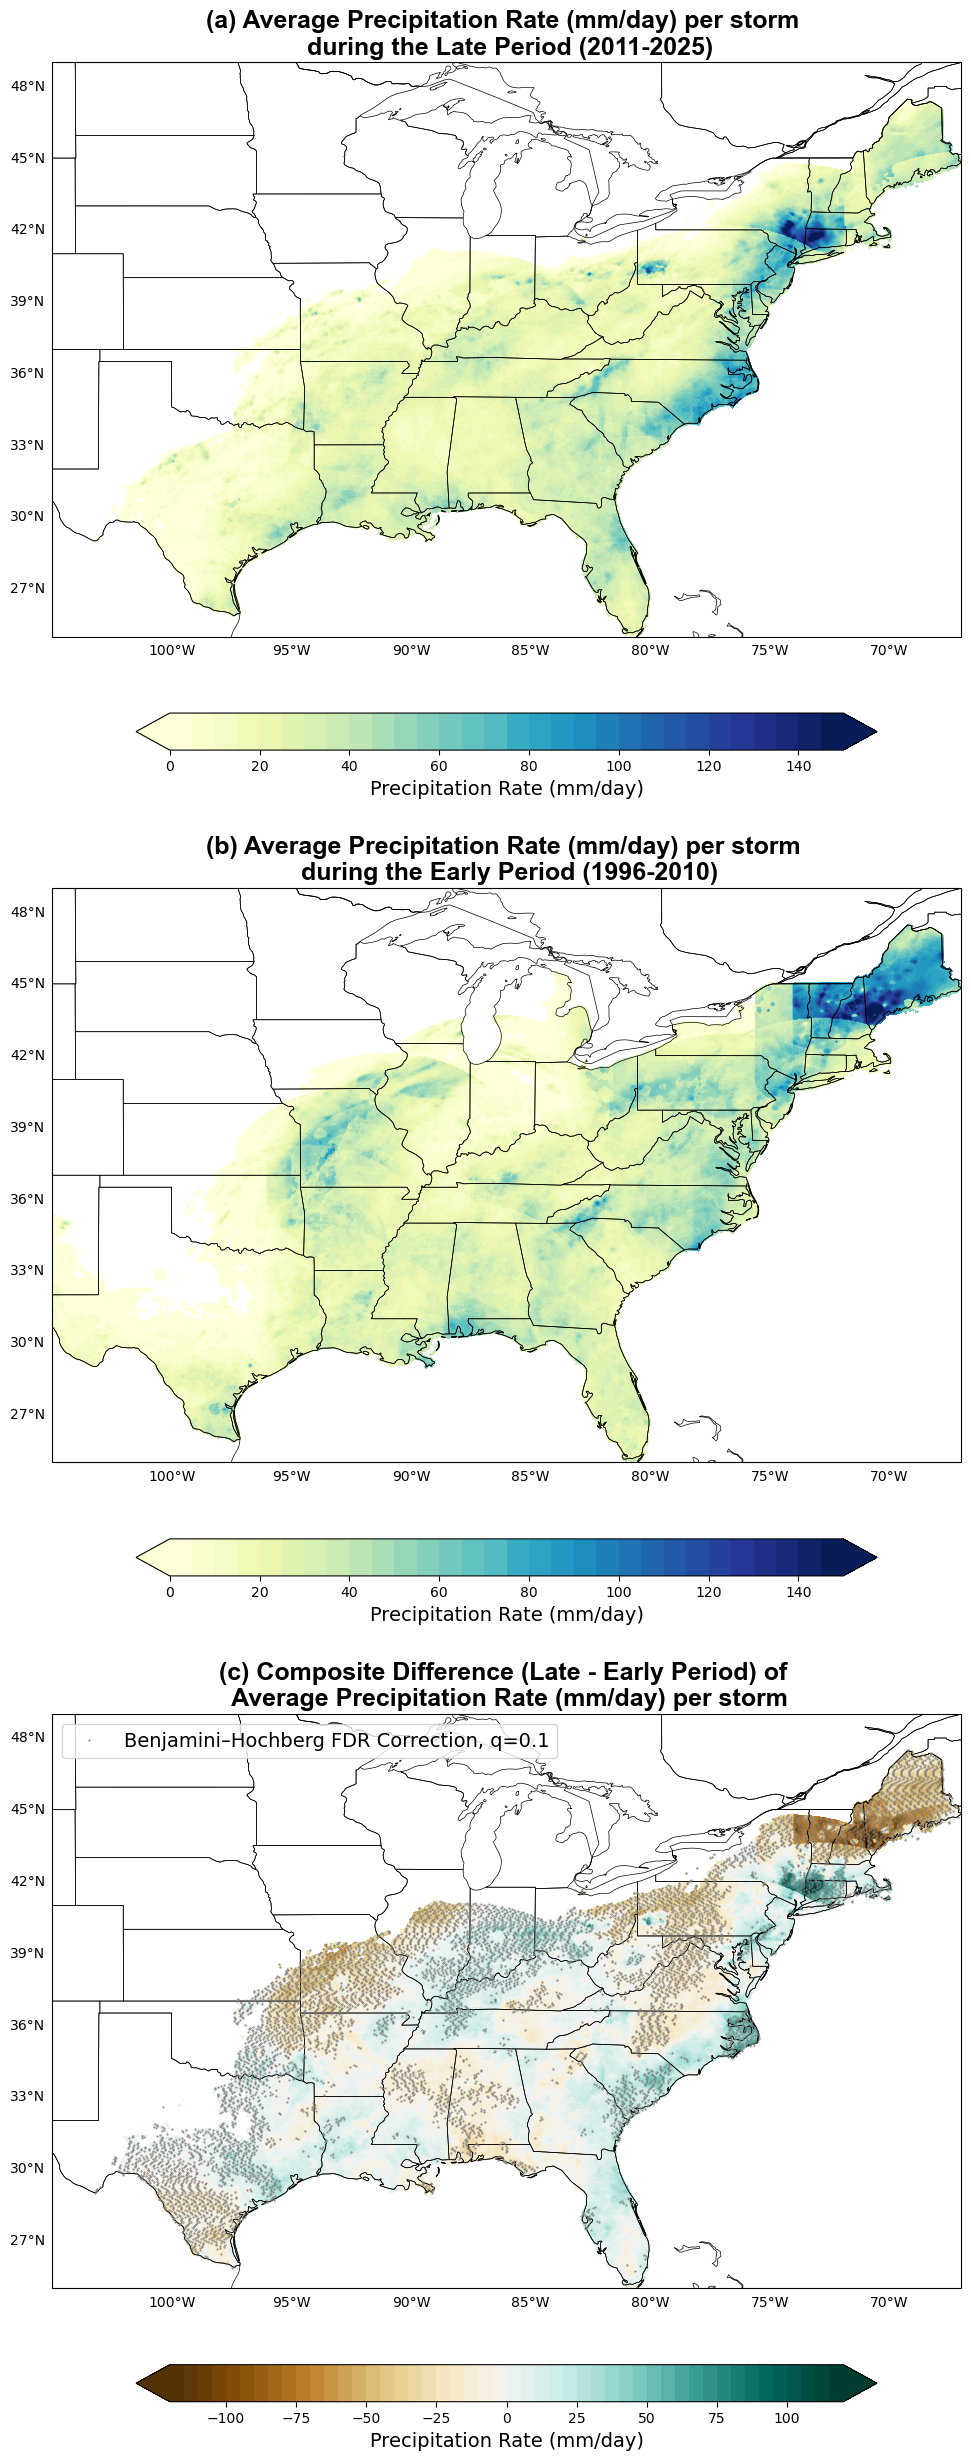

In [48]:
# Contour Information
cmin = -120; cmax = 125; cint = 5
clevs_diff = np.arange(cmin,cmax,cint)
clevs_diff = np.round(clevs_diff,1)

# set up colorbar
cmap_diff = plt.get_cmap(name='BrBG',lut=len(clevs_diff))

cmin = -0; cmax = 155; cint = 5
clevs = np.arange(cmin,cmax,cint)
clevs = np.round(clevs,1)
cmap_comps = plt.get_cmap(name='YlGnBu',lut=len(clevs))

# projection Information
projection = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

# create figure
fig, axs = plt.subplots(3, 1, subplot_kw={'projection': projection}, figsize=(25,25))

# information to be added to each plot (i.e extent of plot, coastlines, borders, states)
extent = [-105, -67, 25, 49]
for ax in axs.flat:
    ax.add_feature(cfeature.COASTLINE,linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,linewidth=0.5)
    ax.add_feature(cfeature.STATES,linewidth=0.5)
    ax.set_extent(extent, crs=data_crs)
    gl = ax.gridlines(crs=data_crs,draw_labels=True, dms=False, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False      
    gl.ylines = False  

# plot composite of late_years and add necessary information (titles, colorbar, label)
late = axs[0].contourf(lon, lat, rl_avg.values, levels=clevs, cmap=cmap_comps, extend='both', transform=data_crs)
axs[0].set_title('(a) Average Precipitation Rate (mm/day) per storm \n during the Late Period (2011-2025)', name='Arial', weight='bold',size=18)
cb_late = fig.colorbar(late, ax=axs[0], orientation='horizontal', pad=0.1, shrink=0.3)
cb_late.set_label('Precipitation Rate (mm/day)', size=14)

# plot composite of early_years and add necessary information (titles, colorbar, label)
early = axs[1].contourf(lon, lat, re_avg.values, levels=clevs, cmap=cmap_comps, extend='both', transform=data_crs)
axs[1].set_title('(b) Average Precipitation Rate (mm/day) per storm \n during the Early Period (1996-2010)', name='Arial', weight='bold',size=18)
cb_early = fig.colorbar(early, ax=axs[1], orientation='horizontal', pad=0.1, shrink=0.3)
cb_early.set_label('Precipitation Rate (mm/day)', size=14)

# plot composite difference and add necessary information (titles, colorbar, label)
diff = axs[2].contourf(lon, lat, comp_diff.values, levels=clevs_diff, cmap=cmap_diff, extend='both',transform=data_crs)
axs[2].set_title('(c) Composite Difference (Late - Early Period) of \n Average Precipitation Rate (mm/day) per storm', name='Arial', weight='bold',size=18)
cb_diff = fig.colorbar(diff, ax=axs[2], orientation='horizontal', pad=0.1, shrink=0.3)
cb_diff.set_label('Precipitation Rate (mm/day)', size=14)

# add stippling to the composite difference map
axs[2].plot(lon[stipple_FDR][::8],lat[stipple_FDR][::8],'o',color='gray',markersize=0.5, transform=data_crs, label='Benjamini–Hochberg FDR Correction, q=0.1') 
axs[2].legend(fontsize=14)

# save fig
plt.tight_layout() 
plt.savefig("CompDiff_Tot.png",dpi=400)

## Further subset by intensity

In [60]:
r_lmn = rl.sel(storm=rl.cat <= 2)
r_lmj = rl.sel(storm=rl.cat > 2)

r_emn = re.sel(storm=re.cat <= 2)
r_emj = re.sel(storm=re.cat > 2)

print (f'Number of Major Hurricanes - Late Period {len(r_lmj)}')
print (f'Number of Major Hurricanes - Early Period {len(r_emj)}')
print (f'Number of Minor Hurricanes - Late Period {len(r_lmn)}')
print (f'Number of Minor Hurricanes - Early Period {len(r_emn)}')

Number of Major Hurricanes - Late Period 10
Number of Major Hurricanes - Early Period 9
Number of Minor Hurricanes - Late Period 18
Number of Minor Hurricanes - Early Period 16


## Repeat compositing process from above for major and minor storms (mean, composite difference, significance, and plot)

In [ ]:
## take per storm mean for each intensity and period
r_lmn_avg = r_lmn.mean(dim='storm', skipna=True)
r_lmj_avg = r_lmj.mean(dim='storm', skipna=True)
r_emn_avg = r_emn.mean(dim='storm', skipna=True)
r_emj_avg = r_emj.mean(dim='storm', skipna=True)

In [ ]:
## compute composit differences
minor_comp_diff = r_lmn_avg - r_emn_avg
major_comp_diff = r_lmj_avg - r_emj_avg

In [ ]:
n1 = len(r_lmn.storm) # Number of late storms
n2 = len(r_emn.storm) # Number of early storms
dof = n1 + n2 - 2 # Degrees of freedom

s1 = r_lmn.std(dim='storm', skipna=True) # late storms standard deviation
s2 = r_emn.std(dim='storm', skipna=True) # early storms standard deviation
sigma = (n1*pow(s1,2) + n2*pow(s2,2))/(n1+n2-1) # Pooled variance 

tStatistic = minor_comp_diff/(np.sqrt(sigma)*np.sqrt(1/n1 + 1/n2)) # from in-class exercise

# p-value at each lat & lon for the two-sided t-test corresponding to each t-score.
pval_mn = 2*stats.t.cdf(-abs(tStatistic),dof*np.ones(tStatistic.shape))

alpha = 0.05
stipple = (pval_mn<=alpha) 

## FDR Level
alpha_FDR = 0.1 

pval_flat = pval_mn.flatten() 


## adjust for nans
mask = ~np.isnan(pval_flat)

adjusted = np.zeros_like(pval_flat)
adjusted[:] = np.nan

adjusted_valid = false_discovery_control(pval_flat[mask], axis=0, method='bh')
adjusted[mask] = adjusted_valid


stipple_FDR_minor = (adjusted < alpha_FDR).reshape(J, I)


## find how many grid points are significant for each method
n_total = J * I
n_tscore = np.sum(stipple) # standard t-test
n_fdr = np.sum(stipple_FDR_minor)

print(f'Total gridpoints : {n_total}')
print(f'Significant (t-test alpha={alpha}): {n_tscore}  ({100*n_tscore/n_total:.1f}%)')
print(f'Significant (FDR  q={alpha_FDR}): {n_fdr}   ({100*n_fdr/n_total:.1f}%)')


## find effective p-value threshold
M = pval_flat.size

sorted_p = np.sort(pval_flat)
K = np.arange(1, pval_flat.size + 1) # ranks
bh_thresh_candidates = sorted_p[sorted_p <= (K / M) * alpha_FDR]
p_FDR_threshold = bh_thresh_candidates[-1] if bh_thresh_candidates.size > 0 else 0.0
print(f'BH p-value threshold used : {p_FDR_threshold:.5f}')


Total gridpoints : 525312
Significant (t-test alpha=0.05): 66174  (12.6%)
Significant (FDR  q=0.1): 64698   (12.3%)
BH p-value threshold used : 0.00960


In [ ]:
n1 = len(r_lmj.storm) # Number of late storms
n2 = len(r_emj.storm) # Number of early storms
dof = n1 + n2 - 2 # Degrees of freedom

s1 = r_lmj.std(dim='storm', skipna=True) # late storms standard deviation
s2 = r_emj.std(dim='storm', skipna=True) # early storms standard deviation
sigma = (n1*pow(s1,2) + n2*pow(s2,2))/(n1+n2-1) # Pooled variance 

tStatistic = major_comp_diff/(np.sqrt(sigma)*np.sqrt(1/n1 + 1/n2)) # from in-class exercise

# p-value at each lat & lon for the two-sided t-test corresponding to each t-score.
pval_mj = 2*stats.t.cdf(-abs(tStatistic),dof*np.ones(tStatistic.shape))

alpha = 0.05
stipple = (pval_mj<=alpha) 

## FDR Level
alpha_FDR = 0.1 

pval_flat = pval_mj.flatten() 


## adjust for nans
mask = ~np.isnan(pval_flat)

adjusted = np.zeros_like(pval_flat)
adjusted[:] = np.nan

adjusted_valid = false_discovery_control(pval_flat[mask], axis=0, method='bh')
adjusted[mask] = adjusted_valid


stipple_FDR_major = (adjusted < alpha_FDR).reshape(J, I)


## find how many grid points are significant for each method
n_total = J * I
n_tscore = np.sum(stipple) # standard t-test
n_fdr = np.sum(stipple_FDR_major)

print(f'Total gridpoints : {n_total}')
print(f'Significant (t-test alpha={alpha}): {n_tscore}  ({100*n_tscore/n_total:.1f}%)')
print(f'Significant (FDR  q={alpha_FDR}): {n_fdr}   ({100*n_fdr/n_total:.1f}%)')


## find effective p-value threshold
M = pval_flat.size

sorted_p = np.sort(pval_flat)
K = np.arange(1, pval_flat.size + 1) # ranks
bh_thresh_candidates = sorted_p[sorted_p <= (K / M) * alpha_FDR]
p_FDR_threshold = bh_thresh_candidates[-1] if bh_thresh_candidates.size > 0 else 0.0
print(f'BH p-value threshold used : {p_FDR_threshold:.5f}')


Total gridpoints : 525312
Significant (t-test alpha=0.05): 54516  (10.4%)
Significant (FDR  q=0.1): 52882   (10.1%)
BH p-value threshold used : 0.00739


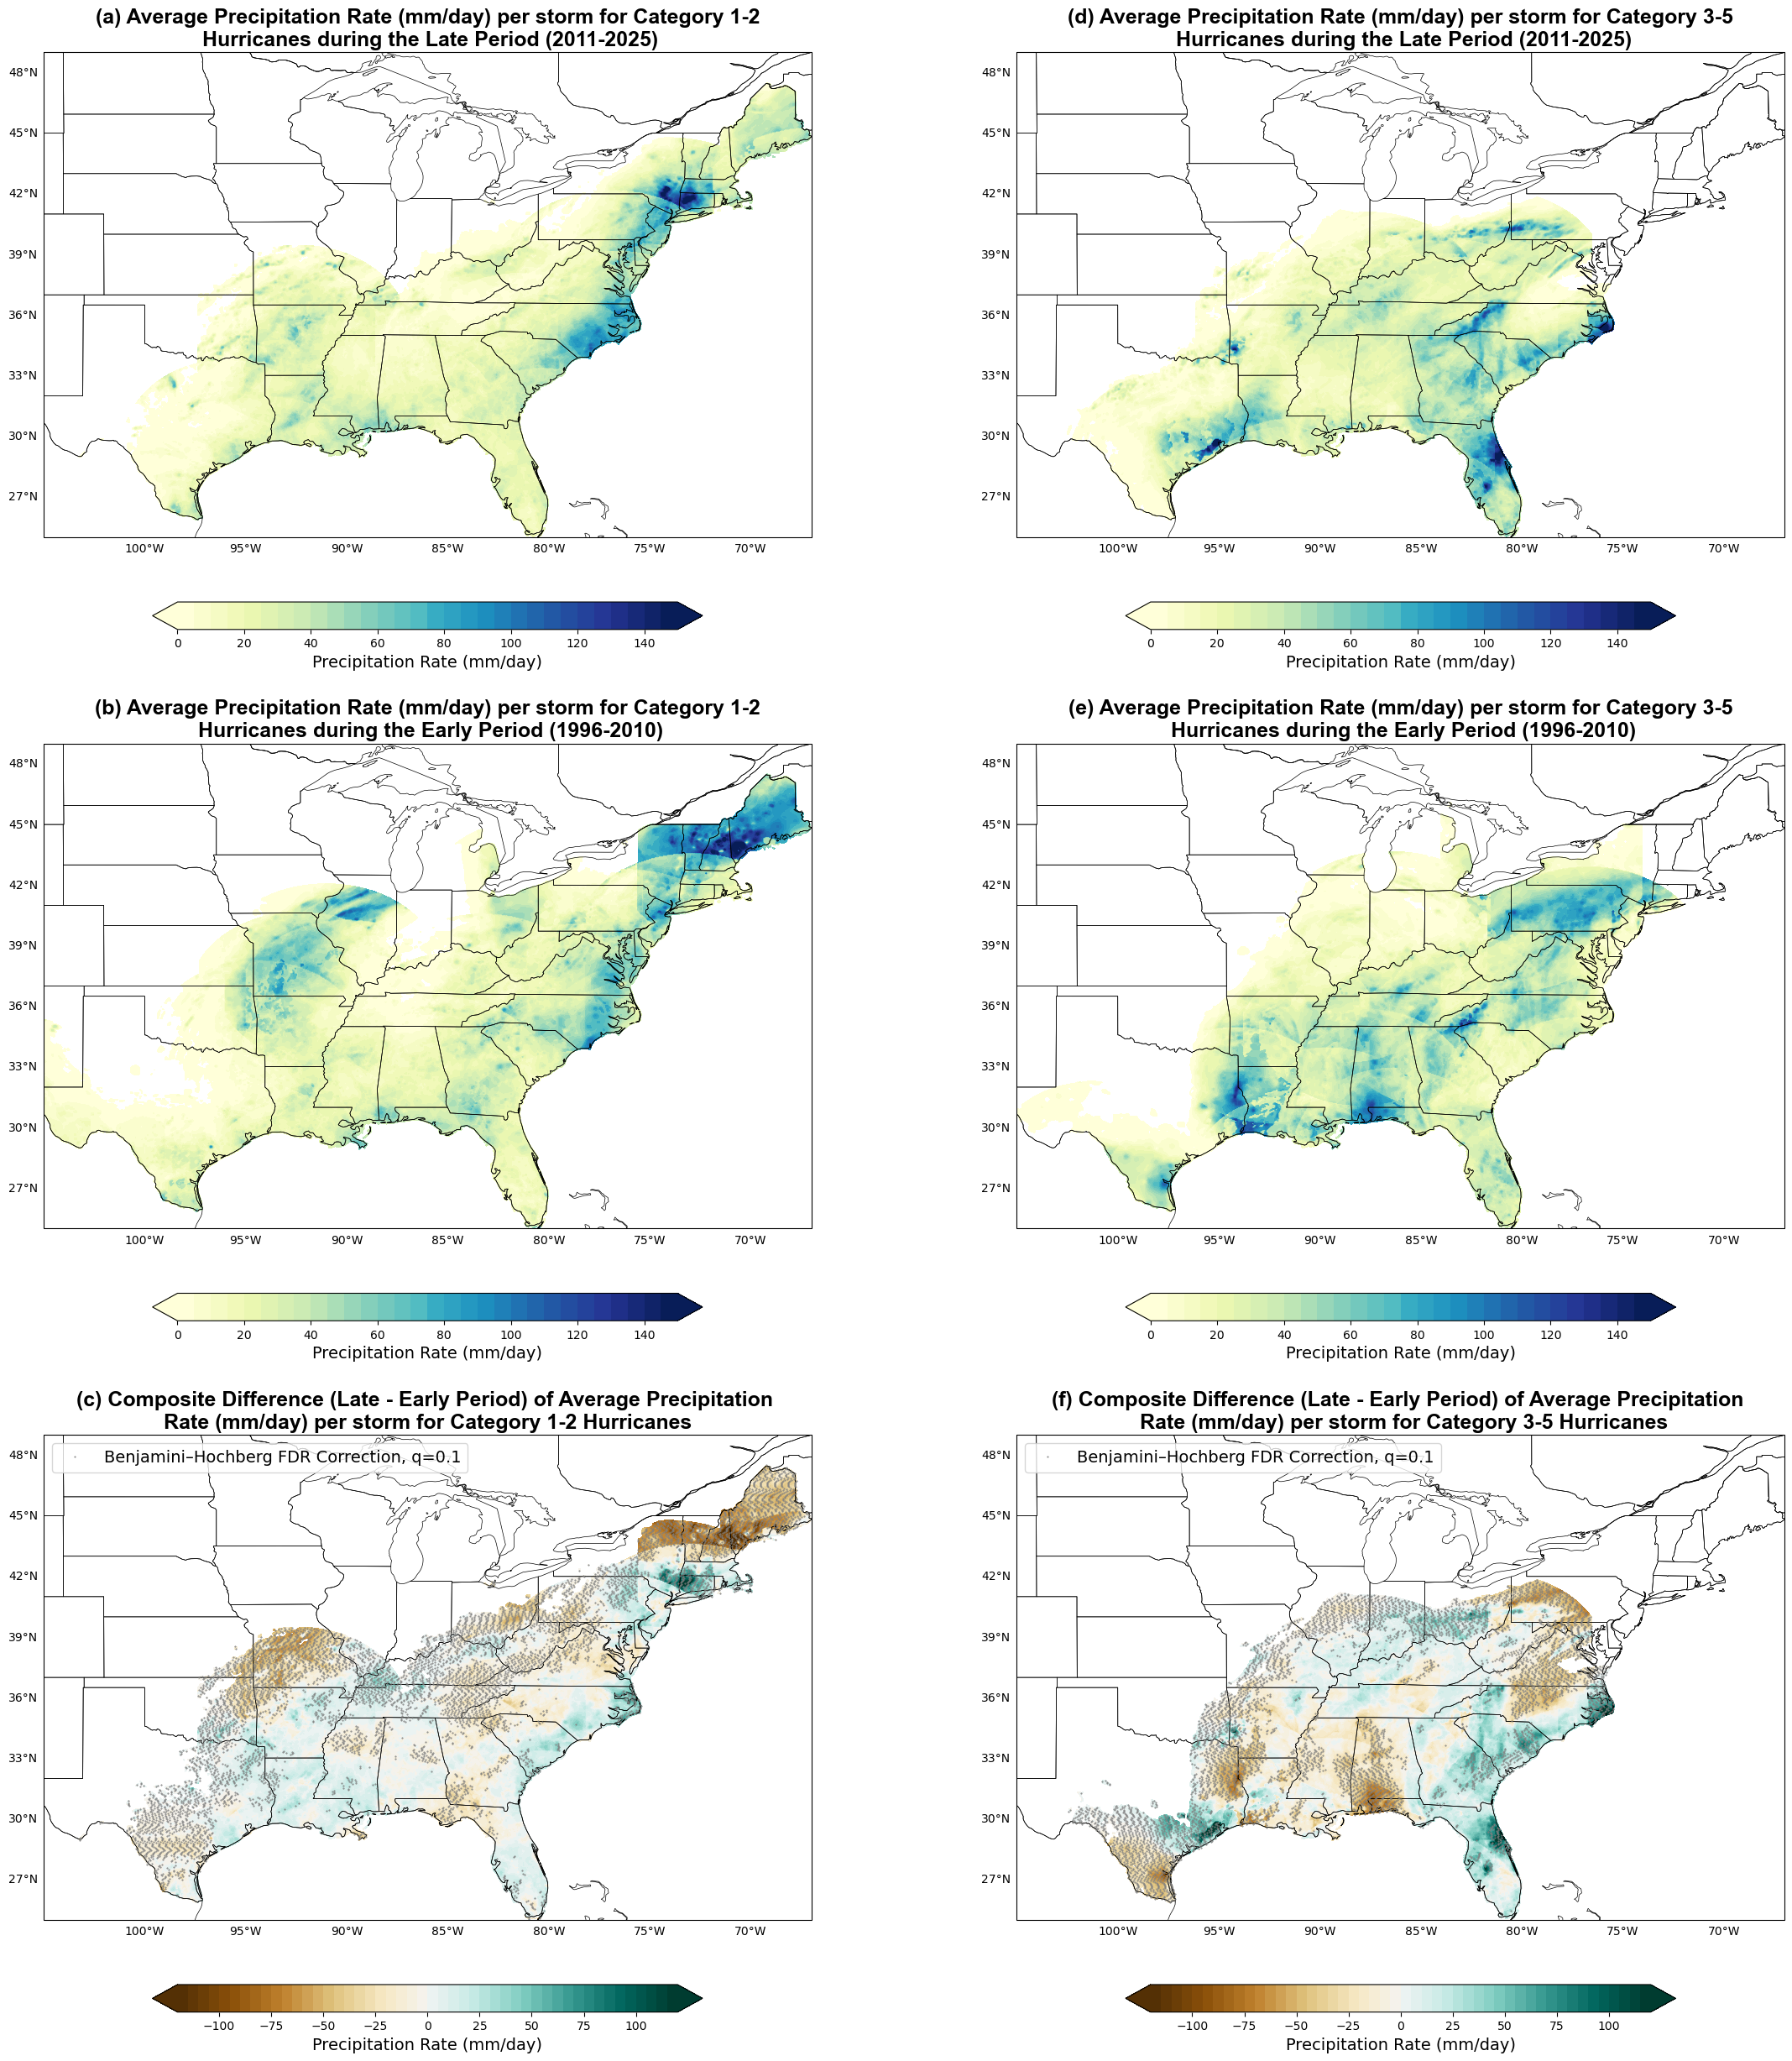

In [54]:
# Contour Information
cmin = -120; cmax = 125; cint = 5
clevs_diff = np.arange(cmin,cmax,cint)
clevs_diff = np.round(clevs_diff,1)

# set up colorbar
cmap_diff = plt.get_cmap(name='BrBG',lut=len(clevs_diff))

cmin = -0; cmax = 155; cint = 5
clevs = np.arange(cmin,cmax,cint)
clevs = np.round(clevs,1)
cmap_comps = plt.get_cmap(name='YlGnBu',lut=len(clevs))

# projection Information
projection = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

# create figure
fig, axs = plt.subplots(3, 2, subplot_kw={'projection': projection}, figsize=(25,25))

# information to be added to each plot (i.e extent of plot, coastlines, borders, states)
extent = [-105, -67, 25, 49]
for ax in axs.flat:
    ax.add_feature(cfeature.COASTLINE,linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,linewidth=0.5)
    ax.add_feature(cfeature.STATES,linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    gl = ax.gridlines(crs=data_crs,draw_labels=True, dms=False, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False      
    gl.ylines = False  

# plot composite of late_minor_years and add necessary information (titles, colorbar, label)
late_mn = axs[0,0].contourf(lon, lat, r_lmn_avg.values, levels=clevs, cmap=cmap_comps, extend='both', transform=data_crs)
axs[0,0].set_title('(a) Average Precipitation Rate (mm/day) per storm for Category 1-2\n Hurricanes during the Late Period (2011-2025)', name='Arial', weight='bold',size=18)
cb_mn_l = fig.colorbar(late_mn, ax=axs[0,0], orientation='horizontal', pad=0.1, shrink=0.5)
cb_mn_l.set_label('Precipitation Rate (mm/day)', size=14)

# plot composite of early_minor_years and add necessary information (titles, colorbar, label)
early_mn = axs[1,0].contourf(lon, lat, r_emn_avg.values, levels=clevs, cmap=cmap_comps, extend='both', transform=data_crs)
axs[1,0].set_title('(b) Average Precipitation Rate (mm/day) per storm for Category 1-2\n Hurricanes during the Early Period (1996-2010)', name='Arial', weight='bold',size=18)
cb_mn_e = fig.colorbar(early_mn, ax=axs[1,0], orientation='horizontal', pad=0.1, shrink=0.5)
cb_mn_e.set_label('Precipitation Rate (mm/day)', size=14)

# plot composite difference and add necessary information (titles, colorbar, label)
diff_mn = axs[2,0].contourf(lon, lat, minor_comp_diff.values, levels=clevs_diff, cmap=cmap_diff, extend='both',transform=data_crs)
axs[2,0].set_title('(c) Composite Difference (Late - Early Period) of Average Precipitation \nRate (mm/day) per storm for Category 1-2 Hurricanes', name='Arial', weight='bold',size=18)
cb_diff_mn = fig.colorbar(diff_mn, ax=axs[2,0], orientation='horizontal', pad=0.1, shrink=0.5)
cb_diff_mn.set_label('Precipitation Rate (mm/day)', size=14)

# add stippling to the composite difference map
axs[2,0].plot(lon[stipple_FDR_minor][::8],lat[stipple_FDR_minor][::8],'o',color='gray',markersize=0.5, transform=data_crs, label='Benjamini–Hochberg FDR Correction, q=0.1') 
axs[2,0].legend(loc='upper left', fontsize=14)

# plot composite of late_major_years and add necessary information (titles, colorbar, label)
late_mj = axs[0,1].contourf(lon, lat, r_lmj_avg.values, levels=clevs, cmap=cmap_comps, extend='both', transform=data_crs)
axs[0,1].set_title('(d) Average Precipitation Rate (mm/day) per storm for Category 3-5\n Hurricanes during the Late Period (2011-2025)', name='Arial', weight='bold',size=18)
cb_mj_l = fig.colorbar(late_mj, ax=axs[0,1], orientation='horizontal', pad=0.1, shrink=0.5)
cb_mj_l.set_label('Precipitation Rate (mm/day)', size=14)

# plot composite of early_major_years and add necessary information (titles, colorbar, label)
early_mj = axs[1,1].contourf(lon, lat, r_emj_avg.values, levels=clevs, cmap=cmap_comps, extend='both', transform=data_crs)
axs[1,1].set_title('(e) Average Precipitation Rate (mm/day) per storm for Category 3-5\n Hurricanes during the Early Period (1996-2010)', name='Arial', weight='bold',size=18)
cb_mj_e = fig.colorbar(early_mj, ax=axs[1,1], orientation='horizontal', pad=0.1, shrink=0.5)
cb_mj_e.set_label('Precipitation Rate (mm/day)', size=14)

# plot composite difference and add necessary information (titles, colorbar, label)
diff_mj = axs[2,1].contourf(lon, lat, major_comp_diff.values, levels=clevs_diff, cmap=cmap_diff, extend='both',transform=data_crs)
axs[2,1].set_title('(f) Composite Difference (Late - Early Period) of Average Precipitation \n Rate (mm/day) per storm for Category 3-5 Hurricanes', name='Arial', weight='bold',size=18)
cb_diff_mj = fig.colorbar(diff_mj, ax=axs[2,1], orientation='horizontal', pad=0.1, shrink=0.5)
cb_diff_mj.set_label('Precipitation Rate (mm/day)', size=14)

# add stippling to the composite difference map
axs[2,1].plot(lon[stipple_FDR_major][::8],lat[stipple_FDR_major][::8],'o',color='gray',markersize=0.5, transform=data_crs, label='Benjamini–Hochberg FDR Correction, q=0.1') 
axs[2,1].legend(loc='upper left', fontsize=14)
# save fig
plt.tight_layout()
plt.savefig("CompDiff_Cat.png",dpi=400)